# Exploratory Data Analysis

Contains 4 Sections:
1. Assessment of Loan Size Prior
2. Assessment of Industry Priors
3. Bivariate Analysis
    - Impact on Default Rates between NAIC sectors and Loan Size
4. Assessment of Model Features
    - Preliminary checks to further understand and validate features to be used in the model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import StrMethodFormatter
from matplotlib import colors
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import scipy.stats

pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")
df = pd.read_sql_table('vw_loans_clean', engine, schema='sba')
df.shape

(348274, 13)

---

## Assessment of Loan Size Prior
*Do larger loans display higher default rates?*

In [2]:
# Split gross approval into ten bins. What are the bin edges?

deciles = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

decile_loan_size = []

for dec in deciles:
    value = np.quantile(df['gross_approval'], dec)
    integer = int(value)
    decile_loan_size.append(integer)

decile_loan_size


[1000,
 15000,
 25000,
 50000,
 65000,
 100000,
 150000,
 250000,
 401840,
 864000,
 5000000]

In [3]:
# Execute binning, display summary data per bin.
# $50-$65K bin has a much smaller loan count than the other bins, and $25K-$50K has a high loan count (both to be addressed in the Bivariate Analysis section).

df['gross_approval_decile'] = pd.qcut(df['gross_approval'], 10)

readable_ranges = {pd.Interval(999.999, 15000, closed='right'): '$1K - $15K',
                   pd.Interval(15000, 25000, closed='right'): '$15K - $25K',
                   pd.Interval(25000, 50000, closed='right'): '$25K - $50K',
                   pd.Interval(50000, 65000, closed='right'): '$50K - $65K',
                   pd.Interval(65000, 100000, closed='right'): '$65K - $100K',
                   pd.Interval(100000, 150000, closed='right'): '$100K - $150K',
                   pd.Interval(150000, 250000, closed='right'): '$150K - $250K',
                   pd.Interval(250000, 401840, closed='right'): '$250K - $402K',
                   pd.Interval(401840, 864000, closed='right'): '$402K - $864K',
                   pd.Interval(864000, 5000000, closed='right'): '$864K - $5MM'}

df['approval_range'] = df['gross_approval_decile'].map(readable_ranges)

decile_chgoffs = df.groupby('approval_range')['is_default'].agg(['sum','count', 'mean']).reset_index() \
            .rename(columns={'sum': 'defaults', 'count': 'total_loans', 'mean': 'default_rate'})

decile_chgoffs.sort_values('approval_range').style.format({'default_rate': '{:.2%}'})

,approval_range,defaults,total_loans,default_rate
0,$1K - $15K,3619,36510,9.91%
1,$15K - $25K,3212,38775,8.28%
2,$25K - $50K,4023,54768,7.35%
3,$50K - $65K,691,10276,6.72%
4,$65K - $100K,2747,38626,7.11%
5,$100K - $150K,3179,34016,9.35%
6,$150K - $250K,2294,32426,7.07%
7,$250K - $402K,2496,33222,7.51%
8,$402K - $864K,2183,34838,6.27%
9,$864K - $5MM,1802,34817,5.18%


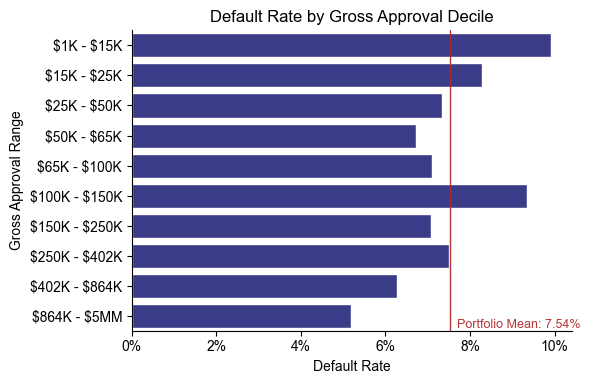

In [4]:
# This visual shows that the default rate generally declines as loan sizes increase.
# The $100K-$150K bin is an outlier that momentarily breaks the trend.

fig, ax = plt.subplots(figsize = (6, 4))
sns.set_theme(style='whitegrid')

sns.barplot(data = decile_chgoffs,
            x = 'default_rate',
            y = decile_chgoffs['approval_range'].str.replace('$', r'\$', regex=False),
            ax = ax,
            color = "#2E3095EC")

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

portfolio_mean = df['is_default'].mean()
ax.axvline(portfolio_mean, color = "#B22828ED", linestyle = '-', linewidth=1)
ax.text(portfolio_mean, ax.get_ylim()[0], f'  Portfolio Mean: {portfolio_mean:.2%}',
        color = "#B22828ED", verticalalignment = 'bottom', fontsize = 9)

ax.set_xlabel('Default Rate')
ax.set_ylabel('Gross Approval Range')
ax.set_title('Default Rate by Gross Approval Decile')
sns.despine()
plt.tight_layout()
plt.show()

In [5]:
# Examine $100-$150K bin, which disrupts the downward trend in default rate as loan size increases. What is its industry composition?

outlier_decile = df[df['gross_approval_decile'] == pd.Interval(left = 100000, right = 150000, closed='right')]

outlier_decile.groupby('naics_sector_description')['is_default'] \
    .agg(np.sum).sort_values(ascending=False).to_frame()

,is_default
naics_sector_description,
Retail Trade,526
Accommodation and Food Services,466
Other Services (except Public Administration),353
Construction,310
"Professional, Scientific, and Technical Services",284
Manufacturing,241
Health Care and Social Assistance,185
Wholesale Trade,183
Administrative and Support and Waste Management and Remediation Services,171


In [6]:
# What does the industry composition look like for the other deciles?

df[df['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')].groupby('naics_sector_description')['is_default'].agg(np.sum) \
    .sort_values(ascending=False).to_frame()

,is_default
naics_sector_description,
Retail Trade,3768
Accommodation and Food Services,3326
Construction,2533
"Professional, Scientific, and Technical Services",2073
Other Services (except Public Administration),1994
Manufacturing,1682
Wholesale Trade,1480
Health Care and Social Assistance,1477
Transportation and Warehousing,1412


In [7]:
# Are the loans in the outlier decile concentrated at a certain loan size?

outlier_decile['gross_approval'].value_counts().head(15).to_frame()

,count
gross_approval,
"150,000.00",16410
"125,000.00",2315
"120,000.00",1418
"140,000.00",934
"130,000.00",886
"110,000.00",813
"135,000.00",714
"115,000.00",530
"145,000.00",451


In [8]:
# There is concentration at $150K. What is the default rate at $150K?

df[df['gross_approval'] == 150000].groupby('gross_approval')[['is_default']].mean() \
    .rename(columns={'is_default': 'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
gross_approval,
150000.000000,11.63%


In [9]:
# Do loans at $150K skew the bin's default rate? What does the default rate look like for all other loan sizes in this bin?

outlier_decile[outlier_decile['gross_approval'] != 150000][['is_default']].mean().to_frame() \
    .rename(index={'is_default': 'Default Rate excl. $150K:'}, columns={0: 'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
Default Rate excl. $150K:,7.21%


### Section Findings
- **My prior expecting larger loans to exhibit higher default rates was incorrect.** Loan size does have an effect on the default rate, but smaller loans exhibit higher default risk while larger loans show lower risk. Borrowers applying for larger loans likely undergo a more rigorous vetting process than borrowers requesting smaller loans. Companies which have been approved for larger loans have likely demonstrated higher viability and stable cash flows while potentially having more years in business on average (this can not be verified due to a high percentage of nulls in business_age).

- I expected smaller businesses would struggle with large loans due to the volatility associated with being a small business. Small businesses experience stronger impacts from fiscal/monetary policy and macroeconomic changes than mid- or large-cap companies, so I believed larger loans would have adverse effects on liquidity, leaving less of a cushion to defend against shocks that could push the company toward insolvency. (This prior was formed under the original FY2000-2019 scope, which spanned recessionary periods, and was carried over when the window narrowed to FY2010-2017. I believe the trend I uncovered likely holds even during recessions, however.)

- Even with the significant loan size range in the last gross approval decile (spanning over $4MM), the default rate is still half that of the first decile, which spans $1K-$15K.

- The $100K-$150K decile exhibited a default rate that broke the downward trend as loan size increased. $150K loans covered 48% of all loans in the decile, and displayed a default rate of 11.63%, substantially higher than the 7.21% default rate of the rest of the loans in the group. This decile also had an industry composition that aligned with the other deciles.

---

## Assessment of Industry Priors
Does Retail carry higher default risk compared to other industries and experience high default rate impact from loan size?

Is Construction's overall default rate in line with the portfolio mean, and does that default rate remain about the same between loan size bins?


**Context:**
 - The mean portfolio default rate is 7.54%, also referred to as the weighted mean (weighted by each NAICS sector's loan count).
 - The unweighted mean default rate is 7.10% (NAICS sectors equally weighted).
 - The unweighted median is 7.59% and is also used as a comparator since it has less influence from outliers.
 - Standard deviation is 1.84%, unweighted. Weighted standard deviation is not used.
 - For chi-square tests of independence, we will use the traditional value of 0.05 as our alpha.

In [10]:
# Summary chart for each NAICS sector. How do their default rates compare to the portfolio mean? Do any sectors have small sample sizes?
# Public Administration appears to be an anomaly judging by its sample size and default rate.

sector_chgoffs = df.groupby(['naics_sector_description'])['is_default'] \
    .agg(['sum','count', 'mean']).reset_index() \
    .sort_values(by='mean', ascending=False) \
    .rename(columns={'sum': 'defaults', 'count': 'total_loans'})

sector_chgoffs.style.format({'mean': '{:.2%}'})

,naics_sector_description,defaults,total_loans,mean
3,"Arts, Entertainment, and Recreation",915,9364,9.77%
14,Public Administration,6,62,9.68%
16,Retail Trade,4294,48763,8.81%
0,Accommodation and Food Services,3792,43171,8.78%
17,Transportation and Warehousing,1543,17913,8.61%
19,Wholesale Trade,1663,19414,8.57%
11,"Mining, Quarrying, and Oil and Gas Extraction",84,1062,7.91%
4,Construction,2843,36558,7.78%
12,Other Services (except Public Administration),2347,30338,7.74%
5,Educational Services,350,4562,7.67%


In [11]:
# Somewhat redundant, but this chart displays the proportion of non-defaults and defaults per industry.

sector_default_spread = df.groupby(['naics_sector_description'])['is_default'].value_counts(normalize=True).unstack() \
                            .rename(columns={0: 'Non-default', 1: 'Default'})
                            
sector_default_spread.style.format({'Non-default': '{:.2%}', 'Default': '{:.2%}'})

is_default,Non-default,Default
naics_sector_description,,
Accommodation and Food Services,91.22%,8.78%
Administrative and Support and Waste Management and Remediation Services,92.59%,7.41%
"Agriculture, Forestry, Fishing and Hunting",94.88%,5.12%
"Arts, Entertainment, and Recreation",90.23%,9.77%
Construction,92.22%,7.78%
Educational Services,92.33%,7.67%
Finance and Insurance,95.72%,4.28%
Health Care and Social Assistance,94.88%,5.12%
Information,92.50%,7.50%


In [12]:
# Identify which loans were provided to retail businesses. Determine whether being a Retail business is associated with the default rate.
# Alpha is 0.05.

df['is_retail'] = df['naics_sector_description'] == 'Retail Trade'
retail_contingency_test = pd.crosstab(df['is_retail'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
retail_contingency_test

is_default,Non-Default,Default
is_retail,,
False,277559,21952
True,44469,4294


In [13]:
# P-value indicates the Retail sector is significantly associated with the default rate.

scipy.stats.chi2_contingency(observed = retail_contingency_test)

Chi2ContingencyResult(statistic=np.float64(131.0020045305545), pvalue=np.float64(2.4735635840325614e-30), dof=1, expected_freq=array([[276939.78967135,  22571.21032865],
       [ 45088.21032865,   3674.78967135]]))

In [14]:
# Prepare independence test for Construction. Is Construction associated with the default rate?

df['is_construction'] = df['naics_sector_description'] == 'Construction'
construction_contingency_test = pd.crosstab(df['is_construction'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
construction_contingency_test

is_default,Non-Default,Default
is_construction,,
False,288313,23403
True,33715,2843


In [15]:
# The p-value of 0.067 indicates Construction does not show a significant association with default, using an alpha of 0.05.
# An alpha of 0.10 would yield the opposite result, so a Type II error is plausible here.

scipy.stats.chi2_contingency(observed = construction_contingency_test)

Chi2ContingencyResult(statistic=np.float64(3.356592394814604), pvalue=np.float64(0.06693644269380317), dof=1, expected_freq=array([[288225.01837059,  23490.98162941],
       [ 33802.98162941,   2755.01837059]]))

In [16]:
# Pull overall portfolio mean and standard deviation. 
# Since different sectors have different loan counts, these values are inherently weighted by the portfolio's NAICS sector distribution.

mean = df[['is_default']].mean()
mean = mean.rename(index={'is_default': 'mean'})

std = df[['is_default']].std(ddof=0)
std = std.rename(index={'is_default': 'std'})

pd.concat(
    [mean, std], axis = 0).to_frame() \
    .rename(columns={0: 'Weighted Mean/Std'}) \
    .style.format({'Weighted Mean/Std': '{:.2%}'}
    )

,Weighted Mean/Std
mean,7.54%
std,26.40%


In [17]:
# Taking the mean of the portfolio mean and standard deviation removes the weighting, allowing all sectors to be equally represented.

unweighted_mean = sector_chgoffs[['mean']].mean()

unweighted_std = sector_chgoffs[['mean']].std(ddof=0)
unweighted_std = unweighted_std.rename(index={'mean': 'std'})

pd.concat(
    [unweighted_mean, unweighted_std], axis = 0).to_frame() \
    .rename(columns={0: 'Unweighted Mean/Std'}) \
    .style.format({'Unweighted Mean/Std': '{:.2%}'}
    )

,Unweighted Mean/Std
mean,7.10%
std,1.84%


In [18]:
# Determine how many stddevs the Retail sector default rate is from the unweighted mean.

retail_sector_diff = sector_default_spread.loc['Retail Trade', 'Default'] - unweighted_mean.reset_index().iloc[0, 1]
retail_stddevs_from_mean = np.round((retail_sector_diff / unweighted_std.reset_index().iloc[0, 1]), 2)
print(f'The retail sector is {retail_stddevs_from_mean} standard deviations from the unweighted mean.')

The retail sector is 0.93 standard deviations from the unweighted mean.


In [19]:
# Repeat for construction.

construction_sector_diff = sector_default_spread.loc['Construction', 'Default'] - unweighted_mean.reset_index().iloc[0, 1]
const_stddevs_from_mean = np.round((construction_sector_diff / unweighted_std.reset_index().iloc[0, 1]), 2)
print(f'The construction sector is {const_stddevs_from_mean} standard deviations from the unweighted mean.')

The construction sector is 0.37 standard deviations from the unweighted mean.


In [20]:
# Pull the median.

np.quantile(sector_chgoffs['mean'], 0.5)

np.float64(0.07585465266739995)

In [21]:
# Determine how many stddevs the Retail sector default rate is from the median.

retail_diff_median = sector_default_spread.loc['Retail Trade', 'Default'] - np.quantile(sector_chgoffs['mean'], 0.5)
retail_stddevs_from_median = np.round((retail_diff_median / unweighted_std.reset_index().iloc[0, 1]), 2)
print(f'The retail sector is {retail_stddevs_from_median} standard deviations from the median.')

The retail sector is 0.66 standard deviations from the median.


In [22]:
# Repeat for construction.

construction_diff_median = sector_default_spread.loc['Construction', 'Default'] - np.quantile(sector_chgoffs['mean'], 0.5)
const_stddevs_from_median = np.round((construction_diff_median / unweighted_std.reset_index().iloc[0, 1]), 2)
print(f'The construction sector is {const_stddevs_from_median} standard deviations from the median.')


The construction sector is 0.1 standard deviations from the median.


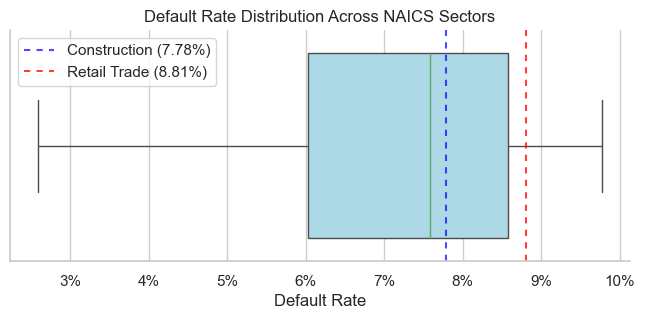

In [23]:
# Visualize Retail and Construction default rates compared to the portfolio median and interquartile range.
# Retail's default rate sits above the 75th percentile and Construction is slightly above the median.

fig, ax = plt.subplots(figsize = (8, 3))
sns.set_style('whitegrid')

sns.boxplot(data = sector_chgoffs, x = 'mean',
            whis = 1.5, ax = ax,
            boxprops={'facecolor': 'lightblue'},
            medianprops={'color': 'g'})

ax.set_xlabel('Default Rate')
ax.set_title('Default Rate Distribution Across NAICS Sectors')
plt.axvline(x = 0.0778, dashes = (3, 3), color = ('blue', .7), label = 'Construction (7.78%)')
plt.axvline(x = 0.0881, dashes = (3, 3), color = ('red', .75), label = 'Retail Trade (8.81%)')

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals = 0))
ax.legend()
sns.despine()
plt.show()

### Section Findings

#### Retail Prior
- Retail's mean default rate of 8.81% falls outside of the IQR, above the 75th percentile. It is nearly one standard deviation (0.93 stddevs) above the unweighted default rate mean of 7.10%, and exactly 1.25ppts above the median of 7.59%. The chi-square test of independence displays a very low p-value (2.47e-30), well below our alpha of 0.05, allowing us to reject the null hypothesis. The test's expected frequencies indicate that the Retail sector would have needed to experience 619 fewer defaults (3675 minus 4294) to be in line with the portfolio mean of 7.54%.

- Retail experienced the third highest default rate amongst the NAICS sectors. Unexpectedly, Arts, Entertainment, and Recreation (AE&R) experienced the highest default rate. AE&R has only 9364 loans reported while Retail has over 5 times that value. Public Administration's default rate is higher than Retail's, but the data is noisy due to their small sample size of 62 loans. I am unsure if these loans are anomalies or genuine. I'd expect a lower default rate for Public Admin; entities in this sector tend to pay slow due to government procedures/management chains, but non-payment is generally unlikely.

- **My prior expecting Retail to display higher than average default risk is accurate.**

#### Construction Prior
- Construction has a default rate of 7.78%, which is within the IQR, about 0.37 standard deviations higher than the unweighted default rate mean (7.10%) and 0.22ppts above the median (7.59%).

- We fail to reject the null hypothesis since our p-value is 0.067 and our alpha is 0.05. These results suggest that Construction does not appear to be significantly associated with the default rate. However, this result is sensitive to the alpha; if we had chosen an alpha of 0.1 instead, we would reject the null instead, leaving the potential for a Type II error. The expected values indicate that Construction had 88 more defaults than average.

- Ultimately, while there is potential for a Type II error, **my prior in which I believed the Construction sector would display average default risk is supported by the results.**

---

Default rate sensitivity to loan size for the Retail and Construction sectors will be tested in the next section.

# Bivariate Analysis
- Loan size + Default Rate, per NAICS sector

In [24]:
# Pull mean sector approval per industry.

mean_sector_approval = df.groupby(['naics_sector_description'])[['gross_approval']].mean().sort_values(by='gross_approval', ascending=False)
mean_sector_approval

,gross_approval
naics_sector_description,
"Agriculture, Forestry, Fishing and Hunting","536,350.23"
Management of Companies and Enterprises,"493,233.68"
Real Estate and Rental and Leasing,"485,527.83"
Accommodation and Food Services,"458,259.62"
"Mining, Quarrying, and Oil and Gas Extraction","432,988.14"
Wholesale Trade,"430,031.21"
Manufacturing,"420,101.91"
Health Care and Social Assistance,"377,147.00"
"Arts, Entertainment, and Recreation","355,530.07"


In [25]:
# Combine datatable with sector summary data from previous section.

full_set = pd.merge(mean_sector_approval, sector_chgoffs, how = 'left', on = 'naics_sector_description') \
            .rename(columns={'mean': 'default_rate'})

full_set.style.format({'gross_approval': '{:.8}', 'default_rate': '{:.2%}'})

,naics_sector_description,gross_approval,defaults,total_loans,default_rate
0,"Agriculture, Forestry, Fishing and Hunting",536350.23,310,6058,5.12%
1,Management of Companies and Enterprises,493233.68,5,193,2.59%
2,Real Estate and Rental and Leasing,485527.83,370,7448,4.97%
3,Accommodation and Food Services,458259.62,3792,43171,8.78%
4,"Mining, Quarrying, and Oil and Gas Extraction",432988.14,84,1062,7.91%
5,Wholesale Trade,430031.21,1663,19414,8.57%
6,Manufacturing,420101.91,1923,28487,6.75%
7,Health Care and Social Assistance,377147.0,1662,32478,5.12%
8,"Arts, Entertainment, and Recreation",355530.07,915,9364,9.77%
9,Finance and Insurance,327533.77,246,5751,4.28%


In [26]:
# Added well ater this notebook was completed for further details on Retail's small loan concentration

print('Proportion of Retail Loans Less than or Equal to $50K: ', np.round(
    int(df[df['naics_sector_description'] == 'Retail Trade'].where(df['gross_approval'] <= 50000)['loan_id'].count()) \
        / int(df[df['naics_sector_description'] == 'Retail Trade']['loan_id'].count()), 2) * 100, "%"
        )

Proportion of Retail Loans Less than or Equal to $50K:  36.0 %


In [27]:
# Added well ater this notebook was completed for further details on Retail's short-term loan concentration

print('Proportion of Retail Loans with 0-60mo terms: ', np.round(
    int(df[df['naics_sector_description'] == 'Retail Trade'].where(df['term_in_months'] <= 60)['loan_id'].count()) \
        / int(df[df['naics_sector_description'] == 'Retail Trade']['loan_id'].count()), 2) * 100, "%"
        )

Proportion of Retail Loans with 0-60mo terms:  20.0 %


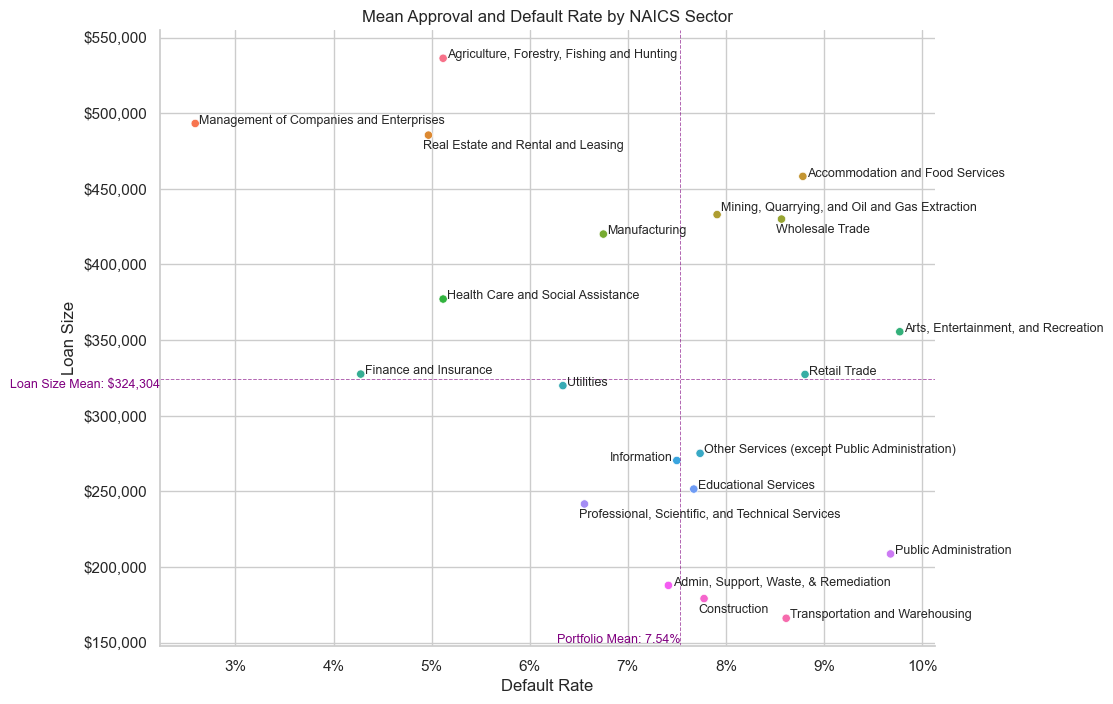

In [28]:
# Plot average default rates and loan sizes for each industry along with the portfolio mean default rate and loan size.
# Retail sits in the upper-right quadrant, showing the heightened default rate along with a average loan size near the portfolio average.
# Construction is in the lower-right quadrant, showing a marginally elevated default rate and significantly lower mean loan size compared to the average.

loan_size_mean = df['gross_approval'].mean()

fig, ax = plt.subplots(figsize = (10, 8))
sns.set_style('whitegrid')
sns.scatterplot(
    data = full_set,
    x = 'default_rate',
    y = 'gross_approval',
    hue = 'naics_sector_description'
)

for i, sec in full_set.iterrows():
    ax.annotate(
        sec['naics_sector_description'] if sec['naics_sector_description'] != \
            'Administrative and Support and Waste Management and Remediation Services' else 'Admin, Support, Waste, & Remediation',

         xy = (sec['default_rate'], sec['gross_approval']),

         xytext = (-4, -10) if sec['naics_sector_description'] in \
            ('Wholesale Trade', 'Professional, Scientific, and Technical Services', \
             'Construction', 'Real Estate and Rental and Leasing') else (-48, 0) if \
                sec['naics_sector_description'] == 'Information' else (3, 3) if \
                    sec['naics_sector_description'] == 'Mining, Quarrying, and Oil and Gas Extraction' else (3, 0),

         textcoords = 'offset points',

         fontsize = 9
    )

plt.axvline(portfolio_mean, color = 'purple', linestyle = '--', linewidth = 0.7, alpha = 0.6)
ax.text(portfolio_mean, ax.get_ylim()[0], f'  Portfolio Mean: {portfolio_mean:.2%}',
        color = 'purple', verticalalignment = 'bottom', horizontalalignment = 'right', fontsize = 9)

plt.axhline(loan_size_mean, color = 'purple', linestyle = '--', linewidth = 0.7, alpha = 0.6)
ax.text(ax.get_xlim()[0], loan_size_mean, f'Loan Size Mean: ${loan_size_mean:,.0f}', 
        color = 'purple', va = 'top', ha = 'right', fontsize = 9)

ax.set_title(label = 'Mean Approval and Default Rate by NAICS Sector')
ax.set_xlabel(xlabel = 'Default Rate')
ax.set_ylabel(ylabel = 'Loan Size')

ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals = 0))

ax.legend_.remove()
sns.despine()
plt.show()

In [29]:
# Determining why the $50K-$65K section only has 10K loans. Loans are most concentrated at $60K.

df[df['gross_approval_decile'] == pd.Interval(50000, 65000, closed = 'right')]['gross_approval'] \
    .value_counts(normalize=True).head(5).to_frame()

,proportion
gross_approval,
"60,000.00",0.30
"65,000.00",0.13
"55,000.00",0.10
"51,000.00",0.03
"52,000.00",0.02


In [30]:
# Determing why the $25K-$50K section has over 50K loans. Nearly half of loans are $50K.

df[df['gross_approval_decile'] == pd.Interval(25000, 50000, closed = 'right')]['gross_approval'] \
    .value_counts(normalize=True).head(5).to_frame()

,proportion
gross_approval,
"50,000.00",0.47
"30,000.00",0.13
"40,000.00",0.10
"35,000.00",0.07
"45,000.00",0.03


In [31]:
# Determine how many loans are at $50K and their default rate.

fifty_mean = df[df['gross_approval'] == 50000]['is_default'].agg('mean')
fifty_count = df[df['gross_approval'] == 50000]['is_default'].agg('count')
print('Default Rate: ', np.round(fifty_mean * 100, 2), '%')
print('Loan Count: ', fifty_count)

Default Rate:  7.92 %
Loan Count:  25628


In [32]:
# Checking loan count and default rate for the maximum 7(a) small loan size, $350K.
# The default rate appears to be slightly elevated, but loan count suggests there is not a high concentration at this value.

max_small_loan_mean = df[df['gross_approval'] == 350000]['is_default'].agg('mean')
max_small_loan_count = df[df['gross_approval'] == 350000]['is_default'].agg('count')
print('Default Rate: ', np.round(max_small_loan_mean * 100, 2), '%')
print('Loan Count: ', max_small_loan_count)

Default Rate:  8.0 %
Loan Count:  6922


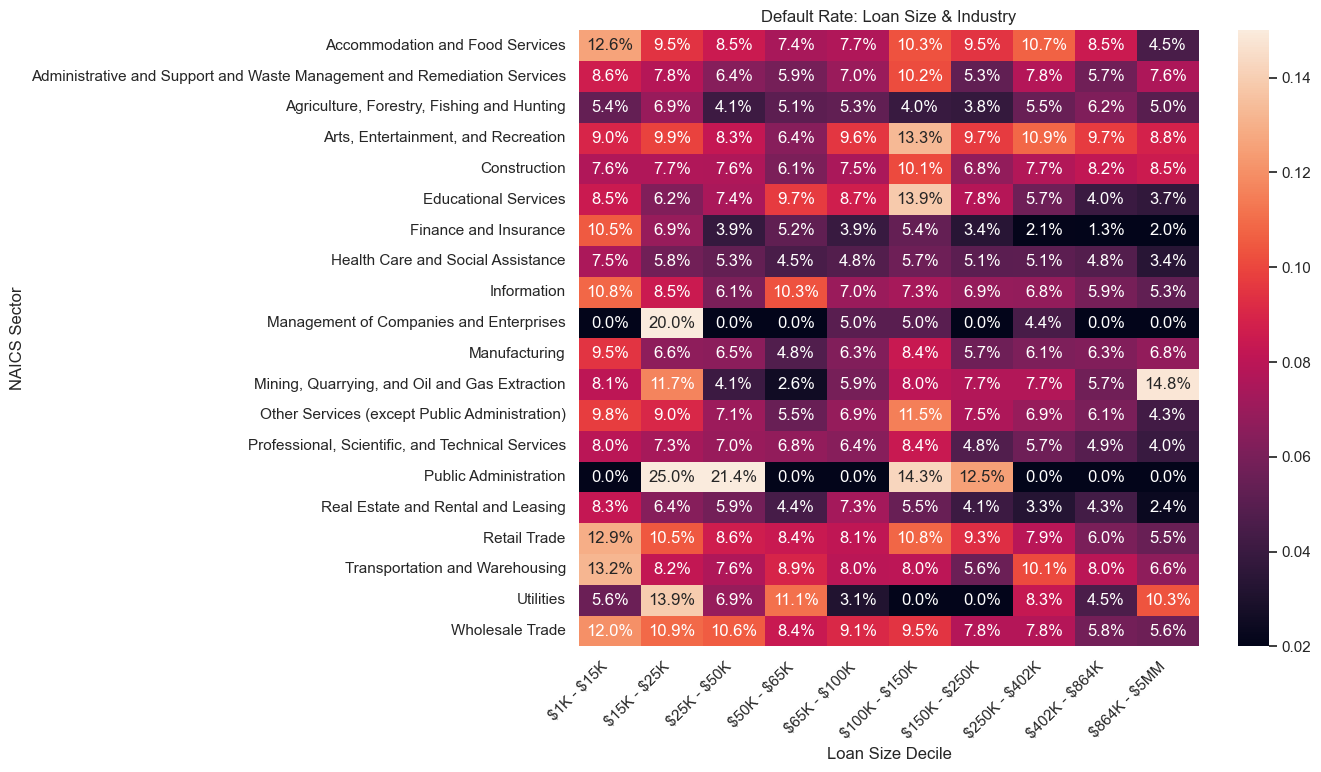

In [33]:
"""
Display default rates for each loan size decile per industry. Not a correlation heatmap.
Retail's default risk generally decreases as loan size increases, along with the portfolio.
Construction's risk slightly increases as loan size increases.
"""

fig, ax = plt.subplots(figsize = (10, 8))

default_rate_by_sector_decile = df.pivot_table(
    index = 'naics_sector_description',
    columns = 'approval_range',
    values = 'is_default',
    aggfunc = 'mean',
    fill_value = None
)

default_rate_by_sector_decile.columns = default_rate_by_sector_decile.columns.str.replace('$', r'\$', regex=False)

sns.heatmap(
    data = default_rate_by_sector_decile,
    cmap = 'rocket',
    vmin = 0.02,
    vmax = 0.15,
    annot = True, fmt = '.1%'
)

plt.xticks(rotation = 45)
ax.set_xlabel(xlabel = 'Loan Size Decile')
ax.set_ylabel(ylabel = 'NAICS Sector')
ax.set_title('Default Rate: Loan Size & Industry')
plt.setp(ax.xaxis.get_majorticklabels(), ha = 'right')
plt.show()

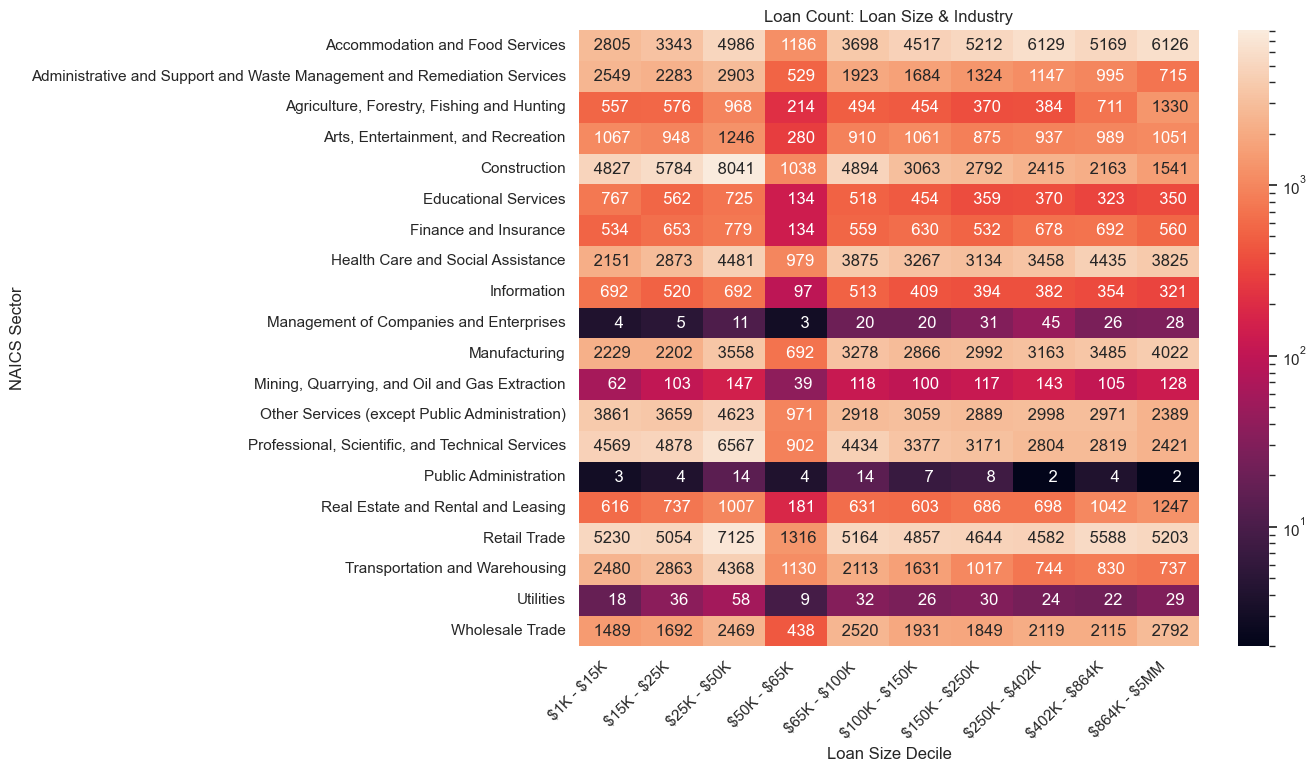

In [34]:
# Display loan count for each loan size decile per industry.
# Loan counts per industry/decile pairing range from 2 to over 8000, so lognorm has been used for the colors.

fig, ax = plt.subplots(figsize = (10, 8))

loan_count_by_sector_decile = df.pivot_table(
    index = 'naics_sector_description',
    columns = 'approval_range',
    values = 'is_default',
    aggfunc = 'count',
    fill_value = None
)

loan_count_by_sector_decile.columns = loan_count_by_sector_decile.columns.str.replace('$', r'\$', regex=False)

sns.heatmap(
    data = loan_count_by_sector_decile,
    cmap = 'rocket',
    norm = colors.LogNorm(),
    annot = True, fmt = '5'
)

plt.xticks(rotation = 45)
ax.set_xlabel('Loan Size Decile')
ax.set_ylabel('NAICS Sector')
ax.set_title('Loan Count: Loan Size & Industry')
plt.setp(ax.xaxis.get_majorticklabels(), ha = 'right')
plt.show()

In [35]:
# Checking the statistics for each decile.

default_rate_by_sector_decile.describe()

approval_range,\$1K - \$15K,\$15K - \$25K,\$25K - \$50K,\$50K - \$65K,\$65K - \$100K,\$100K - \$150K,\$150K - \$250K,\$250K - \$402K,\$402K - \$864K,\$864K - \$5MM
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,0.08,0.10,0.07,0.06,0.06,0.08,0.06,0.07,0.05,0.05
std,0.04,0.05,0.04,0.03,0.02,0.04,0.03,0.03,0.03,0.04
min,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.08,0.07,0.06,0.05,0.05,0.06,0.05,0.05,0.04,0.04
50%,0.09,0.08,0.07,0.06,0.07,0.08,0.06,0.07,0.06,0.05
75%,0.11,0.11,0.08,0.08,0.08,0.10,0.08,0.08,0.06,0.07
max,0.13,0.25,0.21,0.11,0.10,0.14,0.12,0.11,0.10,0.15


In [36]:
# Checking the statistics for gross_approval.

df['gross_approval'].describe().to_frame()

,gross_approval
count,"348,274.00"
mean,"324,304.05"
std,"600,265.35"
min,"1,000.00"
25%,"33,500.00"
50%,"100,000.00"
75%,"325,000.00"
max,"5,000,000.00"


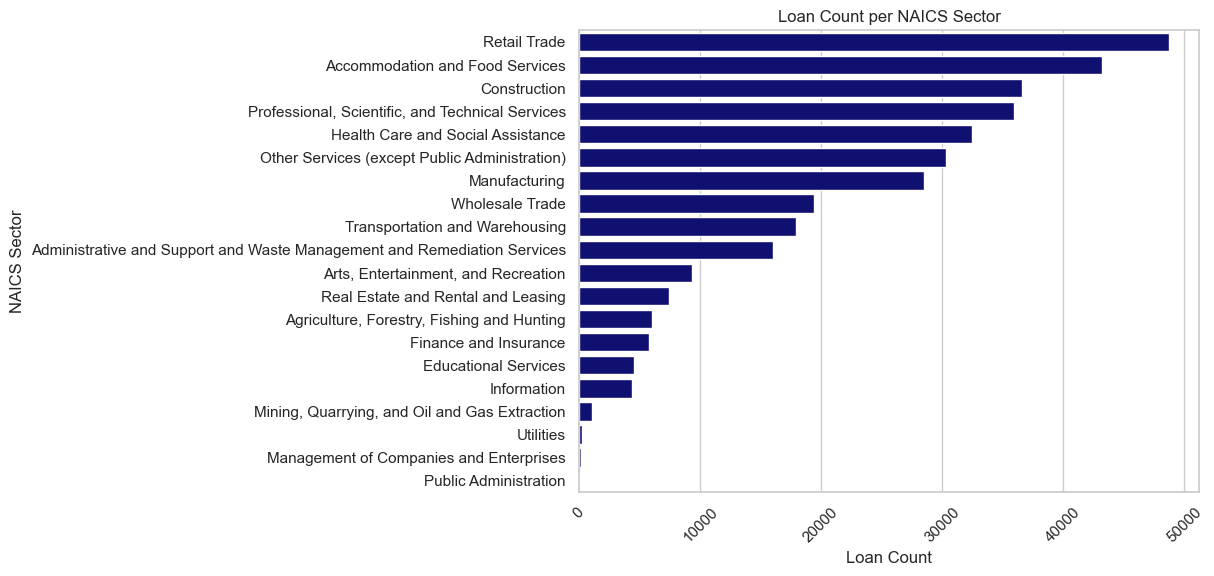

In [37]:
# Visualizing how much influence/weight each sector has on the portfolio.

fig, ax = plt.subplots(figsize = (8, 6))

sns.countplot(
    data = df,
    y = 'naics_sector_description',
    order = df.groupby('naics_sector_description')['loan_id'].count().sort_values(ascending=False).index,
    color = 'navy'
)

plt.xticks(rotation=45)
ax.set_title('Loan Count per NAICS Sector')
ax.set_xlabel('Loan Count')
ax.set_ylabel('NAICS Sector')
plt.show()

In [38]:
# Preparing chi-square test of independence for retail. Is Retail significantly associated with loan size decile?

retail_only = df[df['naics_sector_description'] == 'Retail Trade']
retail_test_loan_size = pd.crosstab(retail_only['gross_approval_decile'], retail_only['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
retail_test_loan_size

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4553,677
"(15000.0, 25000.0]",4525,529
"(25000.0, 50000.0]",6509,616
"(50000.0, 65000.0]",1205,111
"(65000.0, 100000.0]",4745,419
"(100000.0, 150000.0]",4331,526
"(150000.0, 250000.0]",4212,432
"(250000.0, 401840.0]",4219,363
"(401840.0, 864000.0]",5252,336


In [39]:
# This test indicates Retail is significantly associated with loan size decile, which is in line with our findings in the heatmap.

scipy.stats.chi2_contingency(observed = retail_test_loan_size)

Chi2ContingencyResult(statistic=np.float64(289.1593479027879), pvalue=np.float64(5.189721039896383e-57), dof=9, expected_freq=array([[4769.45368415,  460.54631585],
       [4608.95199229,  445.04800771],
       [6497.5826959 ,  627.4173041 ],
       [1200.1149232 ,  115.8850768 ],
       [4709.2655497 ,  454.7344503 ],
       [4429.29953038,  427.70046962],
       [4235.05600558,  408.94399442],
       [4178.51563686,  403.48436314],
       [5095.92871644,  492.07128356],
       [4744.83126551,  458.16873449]]))

In [40]:
# Removing the outlier decile, (100,000-150,000] to ensure test results are not skewed in favor of significance.

retail_excl_sixth_decile = retail_only[retail_only['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')]
retail_test_excl_outlier = pd.crosstab(retail_excl_sixth_decile['gross_approval_decile'], \
                                       retail_excl_sixth_decile['is_default']) \
                                        .rename(columns={0: 'Non-Default', 1: 'Default'})
retail_test_excl_outlier

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4553,677
"(15000.0, 25000.0]",4525,529
"(25000.0, 50000.0]",6509,616
"(50000.0, 65000.0]",1205,111
"(65000.0, 100000.0]",4745,419
"(150000.0, 250000.0]",4212,432
"(250000.0, 401840.0]",4219,363
"(401840.0, 864000.0]",5252,336
"(864000.0, 5000000.0]",4918,285


In [41]:
# Significance is retained even with the exclusion of the outlier decile.

scipy.stats.chi2_contingency(observed = retail_test_excl_outlier)

Chi2ContingencyResult(statistic=np.float64(267.8130665952005), pvalue=np.float64(2.865174850287855e-53), dof=8, expected_freq=array([[4781.16293901,  448.83706099],
       [4620.26720722,  433.73279278],
       [6513.53459664,  611.46540336],
       [1203.06126725,  112.93873275],
       [4720.82703958,  443.17296042],
       [4245.45328657,  398.54671343],
       [4188.77410832,  393.22589168],
       [5108.43948435,  479.56051565],
       [4756.48007106,  446.51992894]]))

In [42]:
# Independence test for Construction.

construction_only = df[df['naics_sector_description'] == 'Construction']
construction_test_loan_size = pd.crosstab(construction_only['gross_approval_decile'], construction_only['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
construction_test_loan_size

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4458,369
"(15000.0, 25000.0]",5341,443
"(25000.0, 50000.0]",7431,610
"(50000.0, 65000.0]",975,63
"(65000.0, 100000.0]",4529,365
"(100000.0, 150000.0]",2753,310
"(150000.0, 250000.0]",2603,189
"(250000.0, 401840.0]",2229,186
"(401840.0, 864000.0]",1986,177


In [43]:
# This test indicates that Construction is significantly associated with loan size, going against my prior.

scipy.stats.chi2_contingency(observed = construction_test_loan_size)

Chi2ContingencyResult(statistic=np.float64(34.6097729063652), pvalue=np.float64(6.980273189948855e-05), dof=9, expected_freq=array([[4451.61948137,  375.38051863],
       [5334.19661907,  449.80338093],
       [7415.67686963,  625.32313037],
       [ 957.27802396,   80.72197604],
       [4513.40910334,  380.59089666],
       [2824.80018054,  238.19981946],
       [2574.87499316,  217.12500684],
       [2227.19309043,  187.80690957],
       [1994.79033317,  168.20966683],
       [1421.16130532,  119.83869468]]))

In [44]:
# Removing the outlier decile and retrying the same test.

construct_excl_sixth_decile = construction_only[construction_only['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')]
construct_test_excl_outlier = pd.crosstab(construct_excl_sixth_decile['gross_approval_decile'], \
                                       construct_excl_sixth_decile['is_default']) \
                                        .rename(columns={0: 'Non-Default', 1: 'Default'})
construct_test_excl_outlier

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4458,369
"(15000.0, 25000.0]",5341,443
"(25000.0, 50000.0]",7431,610
"(50000.0, 65000.0]",975,63
"(65000.0, 100000.0]",4529,365
"(150000.0, 250000.0]",2603,189
"(250000.0, 401840.0]",2229,186
"(401840.0, 864000.0]",1986,177
"(864000.0, 5000000.0]",1410,131


In [45]:
# Test no longer displays a significant association between Construction and loan size judging by p-value of 0.32.

scipy.stats.chi2_contingency(observed = construct_test_excl_outlier)

Chi2ContingencyResult(statistic=np.float64(9.229679993001458), pvalue=np.float64(0.3232926079891859), dof=8, expected_freq=array([[4461.96668159,  365.03331841],
       [5346.59525302,  437.40474698],
       [7432.9136289 ,  608.0863711 ],
       [ 959.50309001,   78.49690999],
       [4523.89992536,  370.10007464],
       [2580.85994925,  211.14005075],
       [2232.36990596,  182.63009404],
       [1999.42695925,  163.57304075],
       [1424.46460666,  116.53539334]]))

In [46]:
# Evaluating $150K loan proportion of all loans across vintages.

loan_count_150 = df[df['gross_approval'] == 150000].groupby('approval_fiscal_year')['is_default'].agg('count').to_frame() \
    .rename(columns={'is_default': '$150K Loan Count'})

loan_count_all = df.groupby('approval_fiscal_year')['is_default'].agg('count').to_frame() \
    .rename(columns={'is_default': 'Total Loans'})

count_compare = pd.concat([loan_count_150, loan_count_all], axis = 1)

count_compare.assign(
    Proportion = count_compare['$150K Loan Count'] / count_compare['Total Loans']
)

,$150K Loan Count,Total Loans,Proportion
approval_fiscal_year,,,
2010,1077,38839,0.03
2011,1408,43926,0.03
2012,1182,37146,0.03
2013,1297,38309,0.03
2014,2322,43384,0.05
2015,3095,51277,0.06
2016,3014,49557,0.06
2017,3015,45836,0.07


In [47]:
# Evaluating proportion of defaults at $150K across vintages.

def_count_150 = df[df['gross_approval'] == 150000].groupby('approval_fiscal_year')['is_default'].agg('sum').to_frame() \
    .rename(columns={'is_default': '$150K Default Count'})

def_count_all = df.groupby('approval_fiscal_year')['is_default'].agg('sum').to_frame() \
    .rename(columns={'is_default': 'Total Defaults'})

default_compare = pd.concat([def_count_150, def_count_all], axis = 1)

default_compare.assign(
    Proportion = default_compare['$150K Default Count'] / default_compare['Total Defaults']
)

,$150K Default Count,Total Defaults,Proportion
approval_fiscal_year,,,
2010,88,3634,0.02
2011,95,3079,0.03
2012,75,2392,0.03
2013,118,2381,0.05
2014,213,2909,0.07
2015,339,3712,0.09
2016,437,3955,0.11
2017,544,4184,0.13


### Section Findings
- LogNorm was chosen as the distribution for the loan count heatmap since the loan count for a given pair can range from 2 to over 8,000, a ratio well exceeding 100x.

- The $50K-65K bucket contains fewer loans overall since the preceding bucket is absorbing all of the $50K loans. All bins are right-closed, meaning the final value listed is included in the bin.

- Loans likely cluster at $150,000 due to program thresholds (maximum guaranty of 85% drops to 75% at $150,001, and fees are 2% at $150,000 and increase to 3% at $150,001). The share of $150K loans grew annually (roughly 3% to 7%), and their share of total defaults rose from 2% to 13% from 2010 to 2017. I could not determine exactly why the default rate increases at this specific loan size using the fields in this dataframe or searching outside sources.

#### Retail Prior
- Retail's loan size distribution is fairly uniform, with the exception of the $50K-$65K bucket.

- Retail's default rates per decile show a clear downward trend, beginning at 13% for the lowest decile and decreasing to 5.5% for the highest decile.

- The default rate of 11% in the $100K-$150K range appears to be an outlier as discussed.

- With an alpha of 0.05, our p-value of 5.19e-57 (and 2.87e-53 with the outlier decile removed) indicates a high level of significance, and we reject the null hypothesis. Retail's default rate is associated with loan size.

- **My prior expecting Retail to be sensitive to loan size is supported by the data.** Admittedly, I did expect the effect to be inverted, with larger loans showing higher default rates, so I was wrong on that belief.

#### Construction Prior
- Loan counts generally decline across higher deciles.

- The wording in my prior may have been unclear. By calling Construction's impact from loan size "average", this meant it would have minimal sensitivity to loan size, displaying fairly consistent default rates across deciles that are near the portfolio mean (7.54%). I did not intend to imply that the sector's impact would resemble that of other industries, in which case we'd expect default rates to decrease as loan size increases.

- The heatmap suggests loan size has minimal impact on Construction's default rates, although there is an outlier in the $100-150K decile and an uptick in the top two deciles. This goes against the trend most sectors have.

- The initial contingency test had a p-value of 6.98e-05, meaning we would reject the null, which would have disproved my prior. However, after removing the $100K-$150K decile, the revised contingency test displayed a p-value of 0.32, indicating a lack of significance when the outlier is excluded.

- **My prior that Construction has low sensitivity to loan size is supported with the exclusion of the outlying decile.**


## Assessment of Model Features

**Assess revolver count default rates and dependency between revolving and term loans.**

In [48]:
# A third of all loans are revolvers.

revolver_count = df['revolver_status'].value_counts()
revolver_count_norm = df['revolver_status'].value_counts(normalize=True)
pd.concat([revolver_count, revolver_count_norm], axis = 1)

,count,proportion
revolver_status,,
False,232792,0.67
True,115482,0.33


In [49]:
# The default rate for revolvers is 0.73ppts lower than the rate for term loans.

df.groupby('revolver_status')[['is_default']].mean() \
    .rename(columns={'is_default':'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
revolver_status,
False,7.78%
True,7.05%


In [50]:
# Setting up independence test.

revolver_contingency_test = pd.crosstab(df['revolver_status'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
revolver_contingency_test

is_default,Non-Default,Default
revolver_status,,
False,214682,18110
True,107346,8136


In [51]:
# P-value of 1.16e-14 indicates strong significance; revolver status is associated with default.

scipy.stats.chi2_contingency(observed = revolver_contingency_test)

Chi2ContingencyResult(statistic=np.float64(59.61233884199672), pvalue=np.float64(1.1550868615941462e-14), dof=1, expected_freq=array([[215248.74718182,  17543.25281818],
       [106779.25281818,   8702.74718182]]))

- Revolving status is significantly associated with default as shown by the p-value in the chi-square test. 33% of loans in this dataset are revolvers, and these loans carry a lower default rate than average.

**Determine if Gross Approval needs to be transformed for the model.**

<Axes: xlabel='gross_approval', ylabel='Count'>

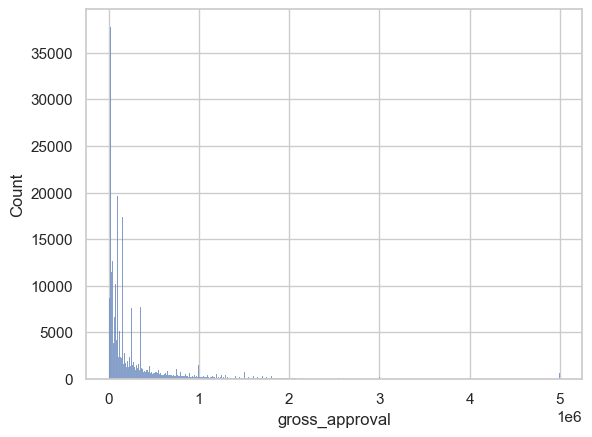

In [52]:
# The gross approval deciles indicate loans are right-skewed. Verifying.

sns.histplot(data = df,
             x = 'gross_approval')

<Axes: xlabel='gross_approval', ylabel='Count'>

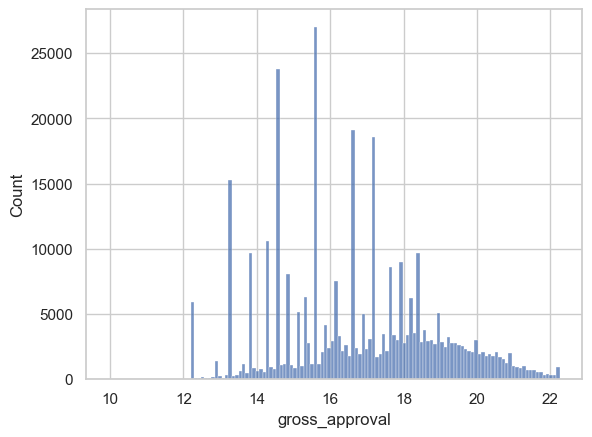

In [53]:
# Transforming to logarithmic scale allows the data to appear more normalized.

sns.histplot(data = df,
             x = np.log2(df['gross_approval'])
)

- Histogram shows a significant right skew. Log makes the data more symmetric, so gross_approval will be transformed to logarithmic scale in the model.

**Determine if term_in_months is viable for the model.**

In [54]:
# Equal-sized bins are not feasible, so terms are split based on common cluster points such as 5 years, the revolver maximum length at 7 years, 10 years, etc.

term_bins_list = [0, 60, 84, 120, 240, 300, 324]

df['term_bin'] = pd.cut(df['term_in_months'], bins = term_bins_list)
df['term_bin'].value_counts().sort_index().to_frame()

,count
term_bin,
"(0, 60]",77096
"(60, 84]",133110
"(84, 120]",73978
"(120, 240]",26253
"(240, 300]",34183
"(300, 324]",3654


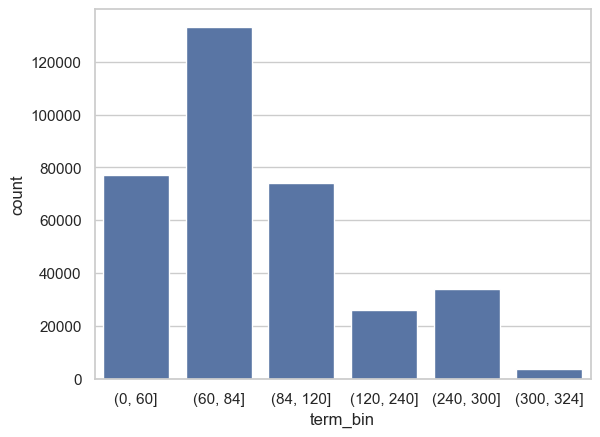

In [55]:
# Quick visualization of the loan distribution between bins.

sns.countplot(data = df,
             x = 'term_bin'
             )

plt.show()

In [ ]:
# Determine average loan size and default rate per bin. Loan size and term length appear to be collinear.
# The short-term bucket shows a high default rate.
# Edited well after EDA was completed.

term_size_comparison = df.groupby('term_bin').agg(
    **{'Default Rate': ('is_default', 'mean'),
     'Loan Size Mean': ('gross_approval', 'mean')}
)

term_size_comparison.style.format({'Default Rate': '{:.2%}',
                                   'Loan Size Mean': '${:,.0f}'})

,Default Rate,Loan Size Mean
term_bin,,
"(0, 60]",19.52%,"$135,658"
"(60, 84]",3.75%,"$104,300"
"(84, 120]",5.97%,"$385,579"
"(120, 240]",4.29%,"$594,138"
"(240, 300]",1.93%,"$1,130,764"
"(300, 324]",0.00%,"$1,595,369"


In [56]:
# Analyzing the defaults in the short-term bucket. Terms seem evenly distributed while loan size seems to cluster below six-figures.

outlier_term_bin = df[(df['term_bin'] == pd.Interval(0, 60, closed = 'right')) & (df['is_default'] == 1)]
outlier_term_bin[['gross_approval', 'term_in_months']].describe()

,gross_approval,term_in_months
count,"15,047.00","15,047.00"
mean,"146,102.19",31.32
std,"292,043.45",17.60
min,"4,400.00",1.00
25%,"25,000.00",16.00
50%,"50,000.00",32.00
75%,"150,000.00",47.00
max,"5,000,000.00",60.00


In [57]:
# 11% of defaults in this bin had loan sizes of $50K.

outlier_term_bin['gross_approval'].value_counts().reset_index().head(15)

,gross_approval,count
0,"50,000.00",1664
1,"25,000.00",1598
2,"10,000.00",1045
3,"100,000.00",943
4,"150,000.00",680
5,"20,000.00",609
6,"15,000.00",576
7,"30,000.00",440
8,"5,000.00",368
9,"75,000.00",335


In [58]:
# Most defaults in this bin are tied to gross approvals of $50K or less.

print('Proportion of Loans Less than or Equal to $50K: ', np.round(
    int(outlier_term_bin['gross_approval'].where(df['gross_approval'] <= 50000).count()) \
        / int(outlier_term_bin['gross_approval'].count()), 2) * 100, "%"
        )

Proportion of Loans Less than or Equal to $50K:  53.0 %


In [61]:
outlier_bin_loans = df[df['term_bin'] == pd.Interval(0, 60, closed = 'right')]

print('Proportion of Loans Less than or Equal to $50K: ', np.round(
    int(outlier_bin_loans['gross_approval'].where(df['gross_approval'] <= 50000).count()) \
        / int(outlier_bin_loans['gross_approval'].count()), 2) * 100, "%"
        )

Proportion of Loans Less than or Equal to $50K:  55.00000000000001 %


**Search for collinearity between terms and revolver status.**

In [ ]:
"""
Find total loans and default rate per each revolver status and bin combination.
The heightened default rate in the lowest bin remains between both revolver statuses.

The default rate generally decreases as terms lengthen for non-revolving accounts.
Revolving accounts do not display the same trend.

Revolving accounts beyond 120 months reflect 10 years revolving/10 years term loans and have a high risk of default amongst a small sample size.
"""

df.groupby(['revolver_status', 'term_bin'])['is_default'].agg(['mean', 'count'])

mean  count
revolver_status term_bin               
False           (0, 60]     0.16  50580
                (60, 84]    0.08  45132
                (84, 120]   0.06  73019
                (120, 240]  0.04  26224
                (240, 300]  0.02  34183
                (300, 324]  0.00   3654
True            (0, 60]     0.25  26516
                (60, 84]    0.02  87978
                (84, 120]   0.02    959
                (120, 240]  0.21     29

In [59]:
"""
Loans with terms of 12 months and less have a default rate of 37% while 13-60 month loans have a default rate of 17%
The values are both significantly above the portfolio mean.
"""

short_term_loans = df[df['term_in_months'] <= 60]
short_term_loans['twelve_month_terms_or_less'] = short_term_loans['term_in_months'].apply(lambda x: 1 if x <= 12 else 0)
short_term_loans.groupby('twelve_month_terms_or_less')['is_default'].agg('mean').to_frame()

,is_default
twelve_month_terms_or_less,
0,0.17
1,0.37


In [60]:
# Checking the term lengths for revolvers with over 10 year terms.

df[(df['term_bin'] == pd.Interval(120, 240, closed = 'right')) & (df['revolver_status'] == 1)] \
    ['term_in_months'].value_counts().to_frame()

,count
term_in_months,
132,3
156,2
144,2
180,2
123,1
204,1
189,1
125,1
167,1


In [61]:
# Revolvers are smaller and shorter than term loans.

df.groupby('revolver_status')[['gross_approval','term_in_months']].median()

,gross_approval,term_in_months
revolver_status,,
False,"180,000.00",120.00
True,"40,000.00",84.00


- The lowest term bin shows a default rate of 20%. Most loans in this bin are $50K or below. Loans with terms of 12 months or less are not solely responsible for the high default rate.

- Revolver status's impact on default rates may be confounded with term length and loan size since revolvers with terms of 60 months and below show a significantly higher risk of default and the majority of defaulted loans with terms of 60 months or less fall within the three smallest gross approval deciles.

- Terms for revolver accounts are capped between 7-10 years depending on loan type. This indicates that some loans flagged as revolvers may be anomalies since a small amount are found with terms above 120 months. The median term length for revolvers is 84 months, in line with the 7 year cap.

**Determine if Collateral Indicator could be a good fit for the model.**

In [62]:
# Collateral_ind is not currently included in the SQL view, so it will be brought in from the raw table.

loans_raw = pd.read_sql_table('loans_raw', engine, schema='sba')
loans_raw.shape

(545751, 43)

In [63]:
# Query removes three records that contained NaN in collateral_ind, reducing total loans in the data set to 348,271.

coll_query = """
WITH coll_join AS (
SELECT *
FROM sba.vw_loans_clean
LEFT JOIN (SELECT loan_id, collateral_ind FROM sba.loans_raw)
USING(loan_id)
WHERE collateral_ind IS NOT NULL
)

SELECT  loan_id,
        loan_status,
        is_default,
        gross_approval,
        approval_fiscal_year,
        term_in_months,
        two_digit_naics_sector,
        naics_sector_description,
        naics_code,
        naics_description,
        revolver_status,
        jobs_supported,
        approval_date,
        CASE WHEN collateral_ind = 'Y' THEN 1
        WHEN collateral_ind = 'N' THEN 0
        ELSE 2 END AS collateral_ind
FROM coll_join;
"""

coll_ind = pd.read_sql_query(coll_query, engine)
coll_ind.shape

(348271, 14)

In [64]:
# Quick sanity check to make sure no nulls made it in.

int(coll_ind[coll_ind['collateral_ind'] == 2]['loan_id'].count())

0

In [65]:
# 71% of loans have collateral reported.

coll_val_counts = pd.concat([coll_ind['collateral_ind'].value_counts(), coll_ind['collateral_ind'].value_counts(normalize=True)], axis = 1)
coll_val_counts

,count,proportion
collateral_ind,,
1,246586,0.71
0,101685,0.29


In [75]:
coll_ind.groupby('collateral_ind')['is_default'].mean().to_frame()

,is_default
collateral_ind,
0,0.10
1,0.07


In [66]:
# 59,253 secured loans have revolving terms.

print(int(coll_ind[(coll_ind['revolver_status'] == 1) & (coll_ind['collateral_ind'] == 1)]['loan_id'].count()))

print('Proportion of secured loans with revolving terms: ', \
      np.round((int(coll_ind[(coll_ind['revolver_status'] == 1) & (coll_ind['collateral_ind'] == 1)]['loan_id'].count()) \
           / coll_val_counts.iloc[0, 0]) * 100, 2), "%")

59253
Proportion of secured loans with revolving terms:  24.03 %


In [67]:
# The majority of unsecured loans have revolving terms.

print(int(coll_ind[(coll_ind['revolver_status'] == 1) & (coll_ind['collateral_ind'] == 0)]['loan_id'].count()))

print('Proportion of unsecured loans with revolving terms: ', \
      np.round((int(coll_ind[(coll_ind['revolver_status'] == 1) & (coll_ind['collateral_ind'] == 0)]['loan_id'].count()) \
           / coll_val_counts.iloc[1, 0]) * 100, 2), "%")

56228
Proportion of unsecured loans with revolving terms:  55.3 %


In [68]:
# Preparing independence test.

coll_contingency_test = pd.crosstab(coll_ind['collateral_ind'], coll_ind['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
coll_contingency_test

is_default,Non-Default,Default
collateral_ind,,
0,92012,9673
1,230013,16573


In [69]:
# Collateral indicator is significantly associated with the default rate.

scipy.stats.chi2_contingency(observed = coll_contingency_test)

Chi2ContingencyResult(statistic=np.float64(804.8600159789078), pvalue=np.float64(4.7359830423381955e-177), dof=1, expected_freq=array([[ 94021.93155617,   7663.06844383],
       [228003.06844383,  18582.93155617]]))

 - Collateral_ind is viable for the model. 71% of loans are secured. Revolvers are disproportionately unsecured, with 55% of revolvers having no collateral. 
 
 - The p-value in the chi-square test indicates collateral status is significantly associated with default.

 - The overlap between collateral_ind, loan size, and revolver status will be assessed via VIF.

In [57]:
df[df['naics_sector_description'] == 'Retail Trade'].where(df['gross_approval'] <= 50000).count()

loan_id                     17409
loan_status                 17409
is_default                  17409
gross_approval              17409
approval_fiscal_year        17409
term_in_months              17409
two_digit_naics_sector      17409
naics_sector_description    17409
naics_code                  17409
naics_description           17397
revolver_status             17409
jobs_supported              17409
approval_date               17409
gross_approval_decile       17409
approval_range              17409
is_retail                   17409
is_construction             17409
term_bin                    17409
dtype: int64

### Section Conclusion
- Gross approval will be transformed to a logarithmic scale for the model.
- Term in months will be used, binned by common maturity caps or lengths.
- Revolver and Collateral_ind will both be used in the model.
- NAICS sector will be used in the model.